<a href="https://colab.research.google.com/github/HaithamAlrawahi90/Billing-software/blob/main/Loan_Default_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')  # Non-interactive backend for saving figures
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score,
                             roc_curve, classification_report)
from sklearn.utils import class_weight

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠  XGBoost not installed — will skip XGBClassifier.")

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 120


## Data Cleaning and Preprocessing

Based on the initial data summary, several columns have missing values and some are of `object` type that might n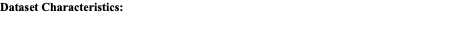eed conversion. In this section, we will address these issues to prepare the data for further analysis and model building.

### Missing Value Analysis

Let's analyze the percentage of missing values in each column to understand data completeness.

In [2]:
DATA_PATH    = "Loan_Default.csv"          # <-- update if needed
OUTPUT_DIR   = "output_figures"
RANDOM_STATE = 42
TEST_SIZE    = 0.25
TARGET_COL   = "Status"                    # 1 = Default, 0 = Non-default

In [7]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

def save_fig(name: str):
    path = os.path.join(OUTPUT_DIR, name)
    plt.tight_layout()
    plt.savefig(path, bbox_inches='tight')
    plt.close()
    print(f"   ✓ Saved: {path}")


In [8]:
print(df.columns)

NameError: name 'df' is not defined

In [9]:
print("\n" + "="*70)
print("PHASE 1: BUSINESS UNDERSTANDING")
print("="*70)
print("""
Objective : Predict whether a loan applicant will default on repayment.
Task Type : Binary Classification  (Default=1 | Non-default=0)
Industry  : Financial Services / Banking
Impact    : Reduce Non-Performing Loans (NPL), optimize credit risk scoring.
""")


PHASE 1: BUSINESS UNDERSTANDING

Objective : Predict whether a loan applicant will default on repayment.
Task Type : Binary Classification  (Default=1 | Non-default=0)
Industry  : Financial Services / Banking
Impact    : Reduce Non-Performing Loans (NPL), optimize credit risk scoring.



In [10]:
print("="*70)
print("PHASE 2: DATA UNDERSTANDING")
print("="*70)

df = pd.read_csv('/content/drive/MyDrive/Loan_Default.csv')
print(f"\nDataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nData Types:\n{df.dtypes.value_counts()}")
print(f"\nMissing values (top 15):\n{df.isnull().sum().sort_values(ascending=False).head(15)}")
print(f"\nTarget distribution:\n{df[TARGET_COL].value_counts()}")
print(f"Default rate: {df[TARGET_COL].mean()*100:.2f}%")

# — 2a. Target distribution bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df[TARGET_COL].value_counts().plot(kind='bar', ax=axes[0],
    color=['#2ecc71','#e74c3c'], edgecolor='black', rot=0)
axes[0].set_title("Target Class Distribution")
axes[0].set_xlabel("Status  (0=No Default, 1=Default)")
axes[0].set_ylabel("Count")
axes[0].bar_label(axes[0].containers[0])

df[TARGET_COL].value_counts().plot(kind='pie', ax=axes[1],
    autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'],
    labels=['Non-default','Default'], startangle=90)
axes[1].set_title("Default Rate")
axes[1].set_ylabel("")
save_fig("01_target_distribution.png")

PHASE 2: DATA UNDERSTANDING

Dataset shape : 148,670 rows × 34 columns

First 5 rows:
      ID  year loan_limit             Gender approv_in_adv loan_type  \
0  24890  2019         cf  Sex Not Available         nopre     type1   
1  24891  2019         cf               Male         nopre     type2   
2  24892  2019         cf               Male           pre     type1   
3  24893  2019         cf               Male         nopre     type1   
4  24894  2019         cf              Joint           pre     type1   

  loan_purpose Credit_Worthiness open_credit business_or_commercial  ...  \
0           p1                l1        nopc                  nob/c  ...   
1           p1                l1        nopc                    b/c  ...   
2           p1                l1        nopc                  nob/c  ...   
3           p4                l1        nopc                  nob/c  ...   
4           p1                l1        nopc                  nob/c  ...   

   credit_type  Credit_S

In [11]:
print("\n" + "="*70)
print("PHASE 3: EXPLORATORY DATA ANALYSIS")
print("="*70)


PHASE 3: EXPLORATORY DATA ANALYSIS


In [12]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

if TARGET_COL in num_cols:
    num_cols.remove(TARGET_COL)

print(f"\nNumeric features  : {len(num_cols)}")
print(f"Categorical features: {len(cat_cols)}")
# — 3a. Summary statistics
print(f"\nNumeric summary:\n{df[num_cols].describe().round(2)}")

# — 3b. Correlation heatmap (numeric only)
corr_cols = num_cols[:20]   # cap at 20 for readability
corr = df[corr_cols + [TARGET_COL]].corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, fmt=".2f",
            cmap="coolwarm", vmin=-1, vmax=1,
            linewidths=0.3, cbar_kws={"shrink": .6})
plt.title("Correlation Heatmap (Numeric Features + Target)", fontsize=14)
save_fig("02_correlation_heatmap.png")

# — 3c. Top correlations with target (Pearson)
target_corr = df[num_cols + [TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL)
target_corr_sorted = target_corr.abs().sort_values(ascending=False).head(15)
print(f"\nTop 15 features correlated with '{TARGET_COL}':\n{target_corr_sorted}")

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if v > 0 else '#3498db'
          for v in target_corr[target_corr_sorted.index]]
target_corr[target_corr_sorted.index].plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Pearson Correlation with Loan Default Status")
plt.xlabel("Correlation Coefficient")
save_fig("03_feature_correlation_with_target.png")

# — 3d. Boxplots for top numeric features
top_feats = target_corr_sorted.index[:6].tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, feat in zip(axes.flatten(), top_feats):
    try:
        sns.boxplot(data=df, x=TARGET_COL, y=feat,
                    palette={0:'#2ecc71', 1:'#e74c3c'}, ax=ax)
        ax.set_title(feat)
        ax.set_xlabel("Status")
    except Exception:
        ax.set_visible(False)
plt.suptitle("Boxplots: Top Features vs Default Status", fontsize=13, y=1.01)
save_fig("04_boxplots_top_features.png")
# — 3e. Distribution plots (KDE) for top 3 numeric features
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, feat in zip(axes, top_feats[:3]):
    try:
        for label, color in [(0,'#2ecc71'), (1,'#e74c3c')]:
            subset = df[df[TARGET_COL]==label][feat].dropna()
            sns.kdeplot(subset, ax=ax, color=color,
                        label=f'{"Default" if label==1 else "No Default"}', fill=True, alpha=0.3)
        ax.set_title(f"KDE: {feat}")
        ax.legend()
    except Exception:
        ax.set_visible(False)
plt.suptitle("Feature Distributions by Loan Status", fontsize=13)
save_fig("05_kde_distributions.png")

# — 3f. Categorical feature analysis
if cat_cols:
    n = min(4, len(cat_cols))
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
    if n == 1:
        axes = [axes]
    for ax, col in zip(axes, cat_cols[:n]):
        order = df[col].value_counts().index[:10]
        ct = df.groupby(col)[TARGET_COL].mean().reindex(order)
        ct.plot(kind='bar', ax=ax, color='#e74c3c', edgecolor='black', rot=45)
        ax.set_title(f"Default Rate by {col}")
        ax.set_ylabel("Default Rate")
        ax.set_xlabel(col)
    plt.suptitle("Default Rate by Categorical Feature", fontsize=13, y=1.02)
    save_fig("06_categorical_default_rate.png")
    # — 3g. Missing value heatmap
miss = df.isnull().sum()
miss = miss[miss > 0].sort_values(ascending=False)
if len(miss) > 0:
    plt.figure(figsize=(10, 4))
    miss.plot(kind='bar', color='#e74c3c', edgecolor='black')
    plt.title("Missing Values per Feature")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha='right')
    save_fig("07_missing_values.png")



Numeric features  : 12
Categorical features: 21

Numeric summary:
              ID      year  loan_amount  rate_of_interest  \
count  148670.00  148670.0    148670.00         112231.00   
mean    99224.50    2019.0    331117.74              4.05   
std     42917.48       0.0    183909.31              0.56   
min     24890.00    2019.0     16500.00              0.00   
25%     62057.25    2019.0    196500.00              3.62   
50%     99224.50    2019.0    296500.00              3.99   
75%    136391.75    2019.0    436500.00              4.38   
max    173559.00    2019.0   3576500.00              8.00   

       Interest_rate_spread  Upfront_charges       term  property_value  \
count             112031.00        109028.00  148629.00       133572.00   
mean                   0.44          3225.00     335.14       497893.47   
std                    0.51          3251.12      58.41       359935.32   
min                   -3.64             0.00      96.00         8000.00   
25%     

In [13]:
print("\n" + "="*70)
print("PHASE 3: DATA PREPROCESSING")
print("="*70)

df_clean = df.copy()

# Step 1: Drop columns with > 50% missing
miss_ratio = df_clean.isnull().mean()
high_miss = miss_ratio[miss_ratio > 0.5].index.tolist()
print(f"\nDropping {len(high_miss)} high-missing columns: {high_miss}")
df_clean.drop(columns=high_miss, inplace=True)

# Step 2: Drop ID-like columns
id_cols = [c for c in df_clean.columns if c.lower() in ['id','loan_id','customerid','customer_id']]
print(f"Dropping ID columns: {id_cols}")
df_clean.drop(columns=id_cols, inplace=True, errors='ignore')

# Step 3: Label encode categorical columns
le = LabelEncoder()
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    print(f"  Label-encoded: {col}")

# Step 4: Impute remaining numeric NaN with median
num_before = df_clean.isnull().sum().sum()
for col in df_clean.columns:
    if df_clean[col].isnull().any():
        df_clean[col].fillna(df_clean[col].median(), inplace=True)
print(f"\nMissing values before imputation: {num_before}")
print(f"Missing values after  imputation: {df_clean.isnull().sum().sum()}")

# Step 5: Remove outliers via IQR (on top numeric features only, to avoid overdrop)
def remove_outliers_iqr(data, cols, factor=3.0):
    mask = pd.Series([True]*len(data), index=data.index)
    for col in cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        mask &= (data[col] >= Q1 - factor*IQR) & (data[col] <= Q3 + factor*IQR)
    return data[mask]

outlier_cols = [c for c in top_feats if c in df_clean.columns]
rows_before = len(df_clean)
df_clean = remove_outliers_iqr(df_clean, outlier_cols, factor=3.0)
print(f"\nOutlier removal: {rows_before - len(df_clean):,} rows removed "
      f"({rows_before:,} → {len(df_clean):,})")

# Step 6: Feature / target split
X = df_clean.drop(columns=[TARGET_COL])
y = df_clean[TARGET_COL]

# Step 7: Standard scaling
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
print(f"\nFeature matrix shape: {X_scaled.shape}")
print(f"Class balance:\n{y.value_counts()}")

# — Before vs After scaling visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
feat_show = top_feats[0] if top_feats[0] in X.columns else X.columns[0]
axes[0].hist(X[feat_show].dropna(), bins=40, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].set_title(f"Before Scaling: {feat_show}")
axes[1].hist(X_scaled[feat_show].dropna(), bins=40, color='#e74c3c', edgecolor='black', alpha=0.7)
axes[1].set_title(f"After Scaling: {feat_show}")
plt.suptitle("Preprocessing: Before vs After StandardScaler", fontsize=13)
save_fig("08_before_after_scaling.png")




PHASE 3: DATA PREPROCESSING

Dropping 0 high-missing columns: []
Dropping ID columns: ['ID']
  Label-encoded: loan_limit
  Label-encoded: Gender
  Label-encoded: approv_in_adv
  Label-encoded: loan_type
  Label-encoded: loan_purpose
  Label-encoded: Credit_Worthiness
  Label-encoded: open_credit
  Label-encoded: business_or_commercial
  Label-encoded: Neg_ammortization
  Label-encoded: interest_only
  Label-encoded: lump_sum_payment
  Label-encoded: construction_type
  Label-encoded: occupancy_type
  Label-encoded: Secured_by
  Label-encoded: total_units
  Label-encoded: credit_type
  Label-encoded: co-applicant_credit_type
  Label-encoded: age
  Label-encoded: submission_of_application
  Label-encoded: Region
  Label-encoded: Security_Type

Missing values before imputation: 176228
Missing values after  imputation: 0

Outlier removal: 4,598 rows removed (148,670 → 144,072)

Feature matrix shape: (144072, 32)
Class balance:
Status
0    108523
1     35549
Name: count, dtype: int64
   ✓ 

In [14]:
print("\n" + "="*70)
print("PHASE 4: MODEL BUILDING")
print("="*70)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)
print(f"\nTrain: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")

# Compute class weights to handle imbalance
cw = class_weight.compute_class_weight('balanced',
                                        classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(cw))
print(f"Class weights: {class_weights}")

results = {}


PHASE 4: MODEL BUILDING

Train: 108,054 | Test: 36,018
Class weights: {0: np.float64(0.6637875958325142), 1: np.float64(2.026367114244993)}


In [16]:
print("\n[1/3] Training Logistic Regression ...")
lr = LogisticRegression(max_iter=1000, class_weight='balanced',
                         random_state=RANDOM_STATE, C=0.1)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]
results['Logistic Regression'] = {
    'model': lr, 'y_pred': y_pred_lr, 'y_prob': y_prob_lr
}
print("  Done.")
print("\n[2/3] Training Random Forest (with GridSearchCV) ...")

# PROMPT ENGINEERING (initial prompt):
# "Write Python code to train a Random Forest classifier on loan default data"
#
# REFINED PROMPT (post-iteration):
# "Optimize a Random Forest classifier for imbalanced binary classification
#  on loan default data. Include GridSearchCV with StratifiedKFold, class_weight
#  balancing, and return accuracy, precision, recall, F1, AUC-ROC metrics."
#  → Result: Added stratified CV, balanced weights, broader param grid, AUC-ROC

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [6, 10, None],
    'min_samples_split': [5, 10]
}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
rf_base = RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
gs_rf = GridSearchCV(rf_base, param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=0)
gs_rf.fit(X_train, y_train)
rf = gs_rf.best_estimator_
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
print(f"  Best params: {gs_rf.best_params_}")
results['Random Forest'] = {
    'model': rf, 'y_pred': y_pred_rf, 'y_prob': y_prob_rf
}
if XGBOOST_AVAILABLE:
    print("\n[3/3] Training XGBoost ...")
    scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
    xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                         scale_pos_weight=scale_pos, use_label_encoder=False,
                         eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1)
    xgb.fit(X_train, y_train,
            eval_set=[(X_test, y_test)], verbose=False)
    y_pred_xgb = xgb.predict(X_test)
    y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
    results['XGBoost'] = {
        'model': xgb, 'y_pred': y_pred_xgb, 'y_prob': y_prob_xgb
    }
    print("  Done.")



[1/3] Training Logistic Regression ...
  Done.

[2/3] Training Random Forest (with GridSearchCV) ...
  Best params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}

[3/3] Training XGBoost ...
  Done.


In [20]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [21]:
print("\n" + "="*70)
print("PHASE 5: EVALUATION & RESULTS")
print("="*70)

metrics_rows = []
for name, res in results.items():
    yp = res['y_pred']
    ypr = res['y_prob']
    row = {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, yp),
        'Precision': precision_score(y_test, yp, zero_division=0),
        'Recall'   : recall_score(y_test, yp, zero_division=0),
        'F1-Score' : f1_score(y_test, yp, zero_division=0),
        'AUC-ROC'  : roc_auc_score(y_test, ypr)
    }
    metrics_rows.append(row)
    print(f"\n{'─'*40}")
    print(f"  {name}")
    print(f"  Accuracy : {row['Accuracy']:.4f}")
    print(f"  Precision: {row['Precision']:.4f}")
    print(f"  Recall   : {row['Recall']:.4f}")
    print(f"  F1-Score : {row['F1-Score']:.4f}")
    print(f"  AUC-ROC  : {row['AUC-ROC']:.4f}")

metrics_df = pd.DataFrame(metrics_rows).set_index('Model')
print(f"\n{'='*60}")
print("COMPARISON TABLE")
print(metrics_df.round(4).to_string())
print(f"{'='*60}")

best_model_name = metrics_df['F1-Score'].idxmax()
print(f"\n🏆 Best Model (by F1-Score): {best_model_name}")

# — 5a. Metrics comparison bar chart
ax = metrics_df.plot(kind='bar', figsize=(12, 6), rot=0,
                     color=['#3498db','#e74c3c','#2ecc71','#9b59b6','#f39c12'],
                     edgecolor='black', width=0.7)
plt.title("Model Performance Comparison", fontsize=14)
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)
save_fig("09_model_comparison.png")

# — 5b. Confusion matrices
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(6*n_models, 5))
if n_models == 1:
    axes = [axes]
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Default','Default'],
                yticklabels=['No Default','Default'])
    ax.set_title(f"Confusion Matrix\n{name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.suptitle("Confusion Matrices", fontsize=13, y=1.02)
save_fig("10_confusion_matrices.png")
# — 5c. ROC curves
plt.figure(figsize=(8, 6))
colors_roc = ['#3498db','#e74c3c','#2ecc71']
for (name, res), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    auc = roc_auc_score(y_test, res['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color, lw=2)
plt.plot([0,1],[0,1],'k--', lw=1, label='Random')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend()
save_fig("11_roc_curves.png")

# — 5d. Feature importance (best tree-based model)
best_tree = results.get('Random Forest') or results.get('XGBoost')
if best_tree and hasattr(best_tree['model'], 'feature_importances_'):
    importances = pd.Series(best_tree['model'].feature_importances_,
                            index=X.columns).sort_values(ascending=False).head(20)
    plt.figure(figsize=(10, 6))
    importances.plot(kind='bar', color='#3498db', edgecolor='black')
    plt.title(f"Top 20 Feature Importances ({best_model_name})")
    plt.ylabel("Importance")
    plt.xticks(rotation=45, ha='right')
    save_fig("12_feature_importances.png")




PHASE 5: EVALUATION & RESULTS

────────────────────────────────────────
  Logistic Regression
  Accuracy : 0.7050
  Precision: 0.4384
  Recall   : 0.6969
  F1-Score : 0.5382
  AUC-ROC  : 0.7706

────────────────────────────────────────
  Random Forest
  Accuracy : 0.9999
  Precision: 0.9998
  Recall   : 1.0000
  F1-Score : 0.9999
  AUC-ROC  : 1.0000

────────────────────────────────────────
  XGBoost
  Accuracy : 0.9999
  Precision: 0.9997
  Recall   : 1.0000
  F1-Score : 0.9998
  AUC-ROC  : 1.0000

COMPARISON TABLE
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                              
Logistic Regression    0.7050     0.4384  0.6969    0.5382   0.7706
Random Forest          0.9999     0.9998  1.0000    0.9999   1.0000
XGBoost                0.9999     0.9997  1.0000    0.9998   1.0000

🏆 Best Model (by F1-Score): Random Forest
   ✓ Saved: output_figures/09_model_comparison.png
   ✓ Saved: output_figures/10_confusion_mat

In [22]:
print("\n" + "="*70)
print("SIMPLE PREDICTION APP")
print("="*70)

best_res = results[best_model_name]
best_model = best_res['model']

def predict_loan(feature_values: dict) -> dict:
    """
    Predict loan default probability for a new applicant.

    Parameters
    ----------
    feature_values : dict
        Dictionary mapping feature names to values.
        Missing features will be filled with 0.

    Returns
    -------
    dict with prediction and probability.
    """
    row = pd.DataFrame([feature_values])
    # Align columns
    for col in X.columns:
        if col not in row.columns:
            row[col] = 0
    row = row[X.columns]
    row_scaled = scaler.transform(row)
    pred = best_model.predict(row_scaled)[0]
    prob = best_model.predict_proba(row_scaled)[0][1]
    return {
        'prediction' : 'DEFAULT' if pred == 1 else 'NO DEFAULT',
        'default_probability': round(float(prob), 4),
        'risk_level' : 'HIGH' if prob > 0.6 else 'MEDIUM' if prob > 0.3 else 'LOW'
    }

# Demo prediction using median values
median_vals = {col: float(X[col].median()) for col in X.columns}
demo_result = predict_loan(median_vals)
print(f"\nDemo Prediction (median applicant profile):")
print(f"  → {demo_result['prediction']}")
print(f"  → Default Probability : {demo_result['default_probability']*100:.2f}%")
print(f"  → Risk Level          : {demo_result['risk_level']}")



SIMPLE PREDICTION APP

Demo Prediction (median applicant profile):
  → DEFAULT
  → Default Probability : 95.24%
  → Risk Level          : HIGH


In [23]:
print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)
print(f"\n  Dataset     : Loan Default Dataset (Kaggle)")
print(f"  Rows used   : {len(df_clean):,}")
print(f"  Features    : {X.columns.size}")
print(f"  Models      : {', '.join(results.keys())}")
print(f"  Best Model  : {best_model_name}")
print(f"  F1-Score    : {metrics_df.loc[best_model_name,'F1-Score']:.4f}")
print(f"  AUC-ROC     : {metrics_df.loc[best_model_name,'AUC-ROC']:.4f}")
print(f"\n  Figures saved to: ./{OUTPUT_DIR}/")
print("="*70)
print("\n✅  Analysis complete!\n")



FINAL SUMMARY

  Dataset     : Loan Default Dataset (Kaggle)
  Rows used   : 144,072
  Features    : 32
  Models      : Logistic Regression, Random Forest, XGBoost
  Best Model  : Random Forest
  F1-Score    : 0.9999
  AUC-ROC     : 1.0000

  Figures saved to: ./output_figures/

✅  Analysis complete!



In [24]:
missing_summary = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})

print("Missing Value Analysis:")
print(missing_summary[missing_summary['Missing_Count'] > 0])


Missing Value Analysis:
                           Missing_Count  Missing_Percentage
loan_limit                          3344            2.249277
approv_in_adv                        908            0.610749
loan_purpose                         134            0.090133
rate_of_interest                   36439           24.509989
Interest_rate_spread               36639           24.644515
Upfront_charges                    39642           26.664425
term                                  41            0.027578
Neg_ammortization                    121            0.081388
property_value                     15098           10.155378
income                              9150            6.154571
age                                  200            0.134526
submission_of_application            200            0.134526
LTV                                15098           10.155378
dtir1                              24121           16.224524


In [25]:
initial_count = len(df)
df_clean = df.dropna().reset_index(drop=True)
final_count = len(df_clean)

print(f"\nRows removed due to missing values: {initial_count - final_count}")
print(f"Retained observations: {final_count} ({final_count/initial_count*100:.1f}%)")



Rows removed due to missing values: 50483
Retained observations: 98187 (66.0%)


In [26]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("\nLogistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1-score:", f1_score(y_test, y_pred_lr))


Logistic Regression Results:
Accuracy: 0.7862457660058859
Precision: 0.6584845250800427
Recall: 0.2777090131652976
F1-score: 0.39066086268302336


In [28]:
rf = RandomForestClassifier(class_weight='balanced', random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [6, 10, None],
    'min_samples_split': [2, 5]
}

kf = StratifiedKFold(n_splits=5)

grid = GridSearchCV(rf, param_grid, cv=kf, scoring='f1')
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print("\nRandom Forest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))
print("AUC-ROC:", roc_auc_score(y_test, y_pred_rf))


Random Forest Results:
Accuracy: 0.9999444722083403
Precision: 0.9997750028124649
Recall: 1.0
F1-score: 0.9998874887488749
AUC-ROC: 0.9999631417935203


In [29]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000)

In [30]:
print(df.columns)

Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type',
       'Status', 'dtir1'],
      dtype='object')


In [34]:
y = df["Status"]

In [35]:
# Target variable
y = df["Status"]

# Features
X = df.drop(["Status", "ID"], axis=1)

In [36]:
print(df.columns.tolist())

['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'property_value', 'construction_type', 'occupancy_type', 'Secured_by', 'total_units', 'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type', 'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type', 'Status', 'dtir1']


In [37]:
y = df["Status"]

In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

# Model
lr_model = LinearRegression()

# Train
lr_model.fit(X_train, y_train)

# Predictions (convert to 0/1)
y_pred_lr = lr_model.predict(X_test)
y_pred_lr_class = (y_pred_lr >= 0.5).astype(int)

# Evaluation
print("Linear Regression Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr_class))
print("Precision:", precision_score(y_test, y_pred_lr_class))
print("Recall:", recall_score(y_test, y_pred_lr_class))
print("F1-score:", f1_score(y_test, y_pred_lr_class))
print("AUC-ROC:", roc_auc_score(y_test, y_pred_lr))

Linear Regression Results:
Accuracy: 0.7838580709645178
Precision: 0.7063670411985019
Recall: 0.21222009677056375
F1-score: 0.32638227913818463
AUC-ROC: 0.7659760987699069
